In [162]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, root_mean_squared_error
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.preprocessing import PowerTransformer
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor, VotingRegressor, BaggingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor
from statsmodels.stats.outliers_influence import variance_inflation_factor
import joblib


In [163]:
df = pd.read_csv('Health_Insurance.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [164]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 94.5 KB


In [165]:
df = df.rename(columns=lambda x: x.strip().title())
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Age       1338 non-null   int64  
 1   Sex       1338 non-null   str    
 2   Bmi       1338 non-null   float64
 3   Children  1338 non-null   int64  
 4   Smoker    1338 non-null   str    
 5   Region    1338 non-null   str    
 6   Charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 94.5 KB


In [166]:
# Removing leading & trailing spaces from data
df = df.apply(lambda x: x.str.strip().str.title() if x.dtype == "str" else x)

In [167]:
df['Region'] = df['Region'].replace({'Northeast': 'NorthEast', 'Northwest': 'NorthWest', 'Southeast': 'SouthEast', 'Southwest': 'SouthWest'})
df['Region'].value_counts()

Region
SouthEast    364
SouthWest    325
NorthWest    325
NorthEast    324
Name: count, dtype: int64

In [168]:
df.isnull().sum()

Age         0
Sex         0
Bmi         0
Children    0
Smoker      0
Region      0
Charges     0
dtype: int64

In [169]:
df.duplicated().sum()

np.int64(1)

In [170]:
df.drop_duplicates()

,Age,Sex,Bmi,Children,Smoker,Region,Charges
0,19,Female,27.900,0,Yes,SouthWest,16884.92400
1,18,Male,33.770,1,No,SouthEast,1725.55230
2,28,Male,33.000,3,No,SouthEast,4449.46200
3,33,Male,22.705,0,No,NorthWest,21984.47061
4,32,Male,28.880,0,No,NorthWest,3866.85520
...,...,...,...,...,...,...,...
1333,50,Male,30.970,3,No,NorthWest,10600.54830
1334,18,Female,31.920,0,No,NorthEast,2205.98080
1335,18,Female,36.850,0,No,SouthEast,1629.83350
1336,21,Female,25.800,0,No,SouthWest,2007.94500


In [171]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1338.0,39.207025,14.049960,18.0000,27.00000,39.000,51.000000,64.00000
Bmi,1338.0,30.663397,6.098187,15.9600,26.29625,30.400,34.693750,53.13000
Children,1338.0,1.094918,1.205493,0.0000,0.00000,1.000,2.000000,5.00000
Charges,1338.0,13270.422265,12110.011237,1121.8739,4740.28715,9382.033,16639.912515,63770.42801


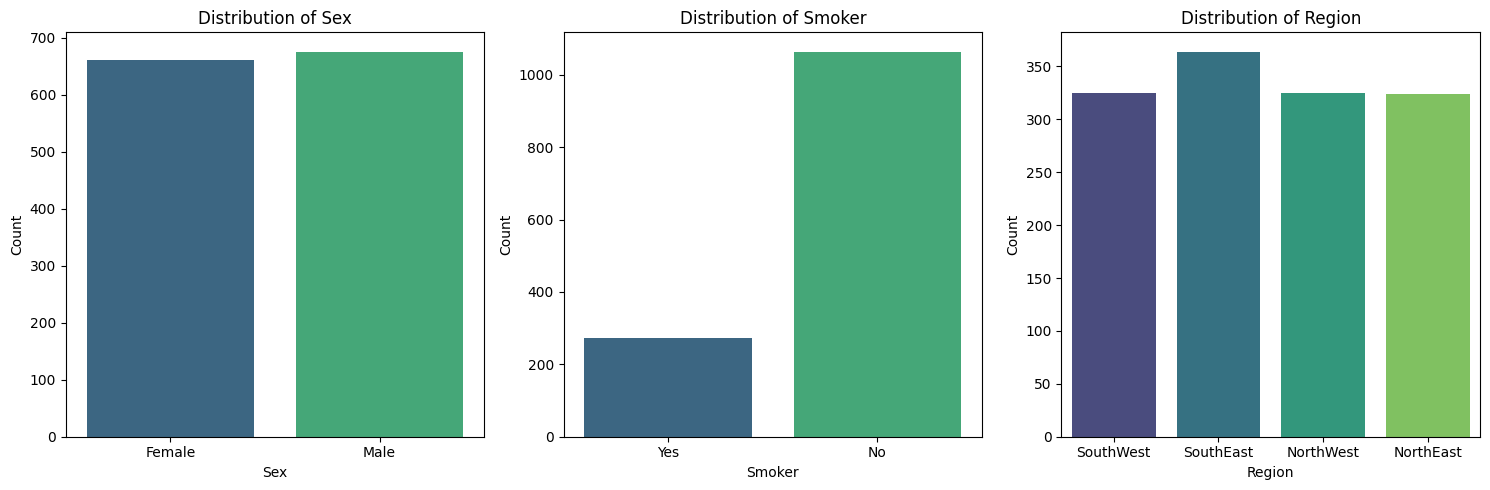

In [172]:
# Visualize the distribution of categorical variables
categorical_cols = df.select_dtypes(include='object').columns

plt.figure(figsize=(15, 5))
for i, col in enumerate(categorical_cols):
    plt.subplot(1, 3, i + 1)
    sns.countplot(x=df[col], palette='viridis')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
plt.tight_layout()
plt.show()

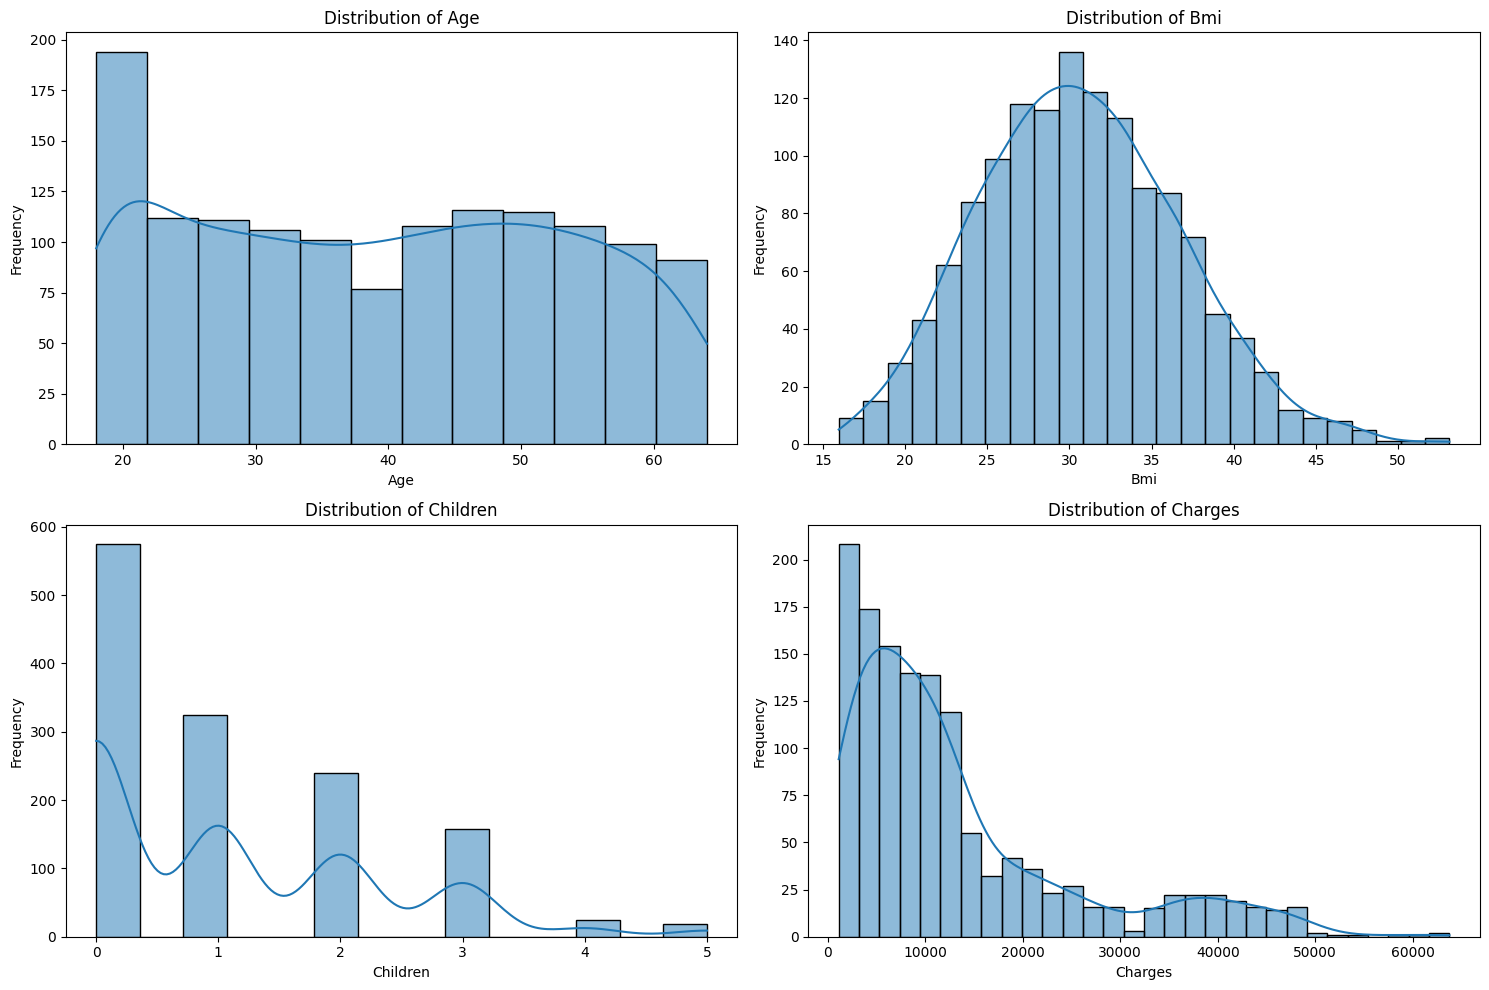

In [173]:
# Visualize the distribution of numerical variables
numerical_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(2, 2, i + 1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

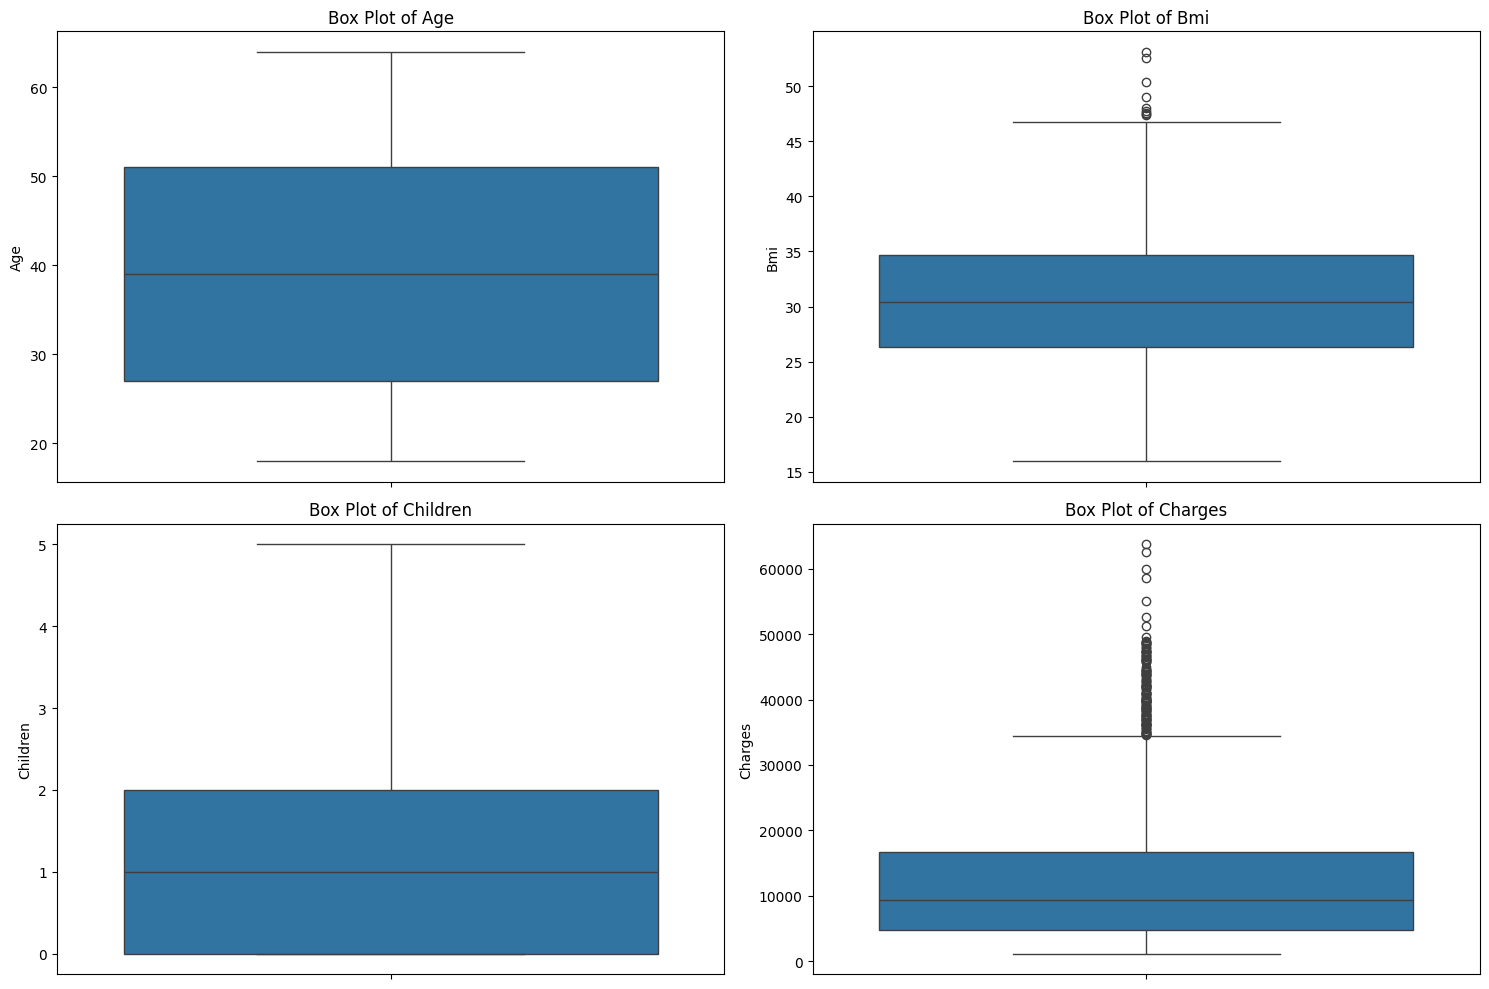

In [174]:
# Visualize the box plots for numerical variables
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(2, 2, i + 1)
    sns.boxplot(y=df[col])
    plt.title(f'Box Plot of {col}')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

In [ ]:
# convert categorical to numeric
#label_encoders = {}

#for col in categorical_cols:
#    label_encoders[col] = LabelEncoder()
#    df[col] = label_encoders[col].fit_transform(df[col])
#    print({label: index for index, label in enumerate(label_encoders[col].classes_)})

In [175]:
# convert categorical to numeric using one-hot encoding
df = pd.get_dummies(df, columns=categorical_cols, dtype=int, drop_first=True)

In [176]:
df.columns

Index(['Age', 'Bmi', 'Children', 'Charges', 'Sex_Male', 'Smoker_Yes',
       'Region_NorthWest', 'Region_SouthEast', 'Region_SouthWest'],
      dtype='str')

In [177]:
df = df.rename(columns={'Sex_Male' : 'Sex', 'Smoker_Yes' : 'Smoker'})
df.columns

Index(['Age', 'Bmi', 'Children', 'Charges', 'Sex', 'Smoker',
       'Region_NorthWest', 'Region_SouthEast', 'Region_SouthWest'],
      dtype='str')

In [178]:
df.head()

,Age,Bmi,Children,Charges,Sex,Smoker,Region_NorthWest,Region_SouthEast,Region_SouthWest
0,19,27.900,0,16884.92400,0,1,0,0,1
1,18,33.770,1,1725.55230,1,0,0,1,0
2,28,33.000,3,4449.46200,1,0,0,1,0
3,33,22.705,0,21984.47061,1,0,1,0,0
4,32,28.880,0,3866.85520,1,0,1,0,0


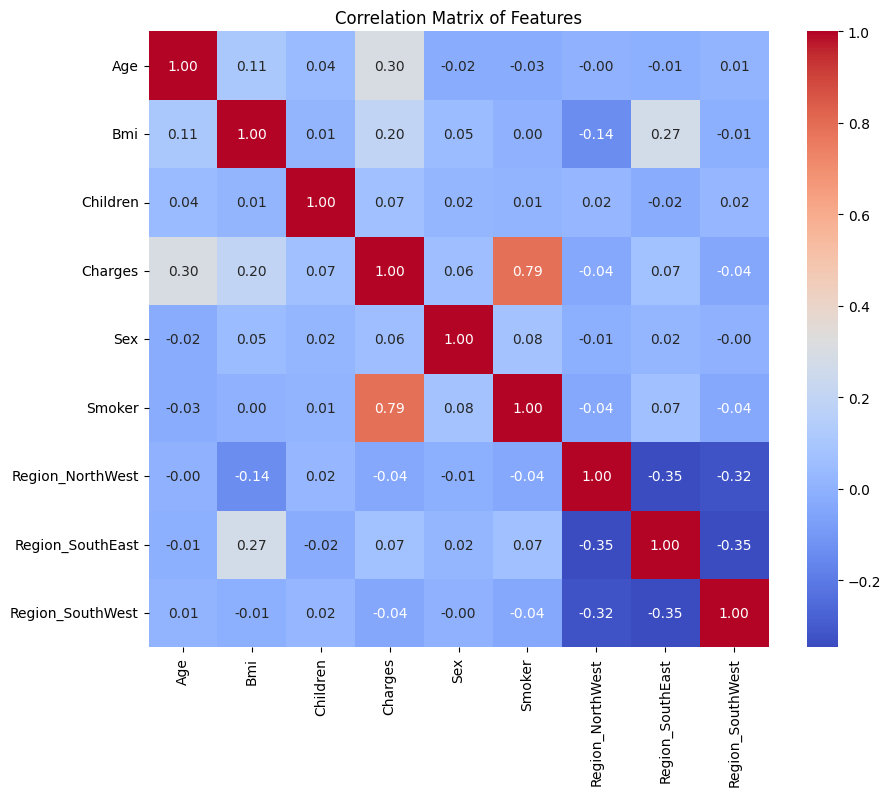

In [179]:
# Calculate the correlation matrix
correlation_matrix = df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Features')
plt.show()

In [180]:
df.skew()

Age                 0.055673
Bmi                 0.284047
Children            0.938380
Charges             1.515880
Sex                -0.020951
Smoker              1.464766
Region_NorthWest    1.200409
Region_SouthEast    1.025621
Region_SouthWest    1.200409
dtype: float64

#### Observations :
##### i. The dataset contains 1337 unique entries after removing one duplicate row, with no missing values.
##### ii. Number of data entries for different Sex & Region classes are balanced.
##### iii. More data entries for non-smoker individuals than smokers.
##### iv. Distribution of Children & Charges are right skewed.
##### v. Few outliers in BMI & Charges.
##### vi. Smoker has highest positive corelation with insurance changes (0.79), followed by Age (0.30) & BMI (0.20)  

#### Function to evaluate model performance

In [181]:
training_r2_scores = []
testing_r2_scores = []
training_adj_r2_scores = []
testing_adj_r2_scores = []
training_rmse_scores = []
testing_rmse_scores = []
training_mae_scores = []
testing_mae_scores = []
overfitting_status = []
overfitting_threshold = 0.05

def ClearMetrics():
    training_r2_scores.clear()
    testing_r2_scores.clear()
    training_adj_r2_scores.clear()
    testing_adj_r2_scores.clear()
    training_rmse_scores.clear()
    testing_rmse_scores.clear()
    training_mae_scores.clear()
    testing_mae_scores.clear()
    overfitting_status.clear()

def EvaluateModel(p_model, p_x_train, p_y_train, p_x_test, p_y_test):
    p_model.fit(p_x_train, p_y_train)
    
    y_train_pred = p_model.predict(p_x_train)
    train_mse = mean_squared_error(p_y_train, y_train_pred)
    train_rmse = np.sqrt(train_mse)
    train_mae = mean_absolute_error(p_y_train, y_train_pred)
    train_r2 = r2_score(p_y_train, y_train_pred)
    train_adj_r2 = 1 - (1 - train_r2) * (len(p_y_train) - 1) / (len(p_y_train) - p_x_train.shape[1] - 1)

    y_test_pred = p_model.predict(p_x_test)
    test_mse = mean_squared_error(p_y_test, y_test_pred)
    test_rmse = np.sqrt(test_mse)
    test_mae = mean_absolute_error(p_y_test, y_test_pred)
    test_r2 = r2_score(p_y_test, y_test_pred)
    test_adj_r2 = 1 - (1 - test_r2) * (len(p_y_test) - 1) / (len(p_y_test) - p_x_test.shape[1] - 1)

    training_r2_scores.append(np.round(train_r2, 4))
    testing_r2_scores.append(np.round(test_r2, 4))
    training_adj_r2_scores.append(np.round(train_adj_r2, 4))
    testing_adj_r2_scores.append(np.round(test_adj_r2, 4))
    training_rmse_scores.append(np.round(train_rmse, 4))
    testing_rmse_scores.append(np.round(test_rmse, 4))
    training_mae_scores.append(np.round(train_mae, 4))
    testing_mae_scores.append(np.round(test_mae, 4))
    overfitting_status.append("Y" if abs(train_r2 - test_r2) > overfitting_threshold else "N")

In [182]:
def EndToEndEvaluation(p_models, p_x_train, p_y_train, p_x_test, p_y_test):
    ClearMetrics()
    for l_model in p_models:
        EvaluateModel(l_model, p_x_train, p_y_train, p_x_test, p_y_test)

    results_df = pd.DataFrame({
        'Model': [model.__class__.__name__ for model in p_models],
        'Train R2': training_r2_scores,
        'Test R2': testing_r2_scores,
        'Train Adjusted R2': training_adj_r2_scores,
        'Test Adjusted R2': testing_adj_r2_scores,
        'Train RMSE': training_rmse_scores,
        'Test RMSE': testing_rmse_scores,
        'Train MAE': training_mae_scores,
        'Test MAE': testing_mae_scores,
        'Overfitting (Y/N)': overfitting_status
    })

    results_df = results_df.sort_values(by='Test R2', ascending=False).reset_index(drop=True)
    return results_df

In [183]:
models = [
    LinearRegression(),
    Ridge(),
    Lasso(),
    ElasticNet(),
    DecisionTreeRegressor(random_state=42),
    RandomForestRegressor(random_state=42),
    SVR(),
    KNeighborsRegressor(),
    GradientBoostingRegressor(random_state=42),
    AdaBoostRegressor(random_state=42),
    XGBRegressor(random_state=42),
    VotingRegressor(estimators=[
        ('lr', LinearRegression()),
        ('svr', SVR()),
        ('knn', KNeighborsRegressor()),
        ('rf', RandomForestRegressor(random_state=42))
    ])
]

#### Evaluate without EDA

In [184]:
df_without_eda = df.copy()

x = df_without_eda.drop(columns=['Charges'])
y = df_without_eda['Charges']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

print("Model evaluation without EDA :")
EndToEndEvaluation(models, x_train, y_train, x_test, y_test)

Model evaluation without EDA :


,Model,Train R2,Test R2,Train Adjusted R2,Test Adjusted R2,Train RMSE,Test RMSE,Train MAE,Test MAE,Overfitting (Y/N)
0,GradientBoostingRegressor,0.8996,0.8792,0.8989,0.8754,3806.3766,4331.1813,2096.5810,2446.2028,N
1,RandomForestRegressor,0.9740,0.8652,0.9738,0.8611,1938.3838,4574.1425,1066.7000,2546.2638,Y
2,XGBRegressor,0.9943,0.8491,0.9943,0.8444,904.7197,4840.9405,479.3838,2765.7468,Y
3,AdaBoostRegressor,0.8146,0.8213,0.8132,0.8158,5173.0364,5267.0605,4258.3126,4421.2593,N
4,LinearRegression,0.7417,0.7836,0.7398,0.7769,6105.5452,5796.2847,4208.2346,4181.1945,N
5,Lasso,0.7417,0.7835,0.7398,0.7769,6105.5502,5797.0258,4208.5835,4182.4260,N
6,Ridge,0.7417,0.7833,0.7398,0.7766,6105.7912,5800.4342,4217.8874,4193.5853,N
7,DecisionTreeRegressor,0.9983,0.6968,0.9983,0.6874,494.2060,6861.2411,29.5725,3384.4735,Y
8,VotingRegressor,0.7189,0.6657,0.7168,0.6553,6369.9464,7204.4039,4131.5061,4840.6980,Y
9,ElasticNet,0.3831,0.4186,0.3785,0.4006,9435.9379,9500.9499,7281.4102,7423.8554,N


#### Perform EDA

In [185]:
df_eda = df.copy()

In [186]:
df_eda.skew()

Age                 0.055673
Bmi                 0.284047
Children            0.938380
Charges             1.515880
Sex                -0.020951
Smoker              1.464766
Region_NorthWest    1.200409
Region_SouthEast    1.025621
Region_SouthWest    1.200409
dtype: float64

In [187]:
df_eda['Children'] = np.log1p(df_eda['Children'])

In [188]:
df_eda.skew()

Age                 0.055673
Bmi                 0.284047
Children            0.264083
Charges             1.515880
Sex                -0.020951
Smoker              1.464766
Region_NorthWest    1.200409
Region_SouthEast    1.025621
Region_SouthWest    1.200409
dtype: float64

#### Among actual numerical variables, 'Children' & 'Chrages' are positively skewed. As 'Charges' is the target variables,, we are not going to handle skewness for 'Charges'. Handled skewness for 'Children' with log transformation. 

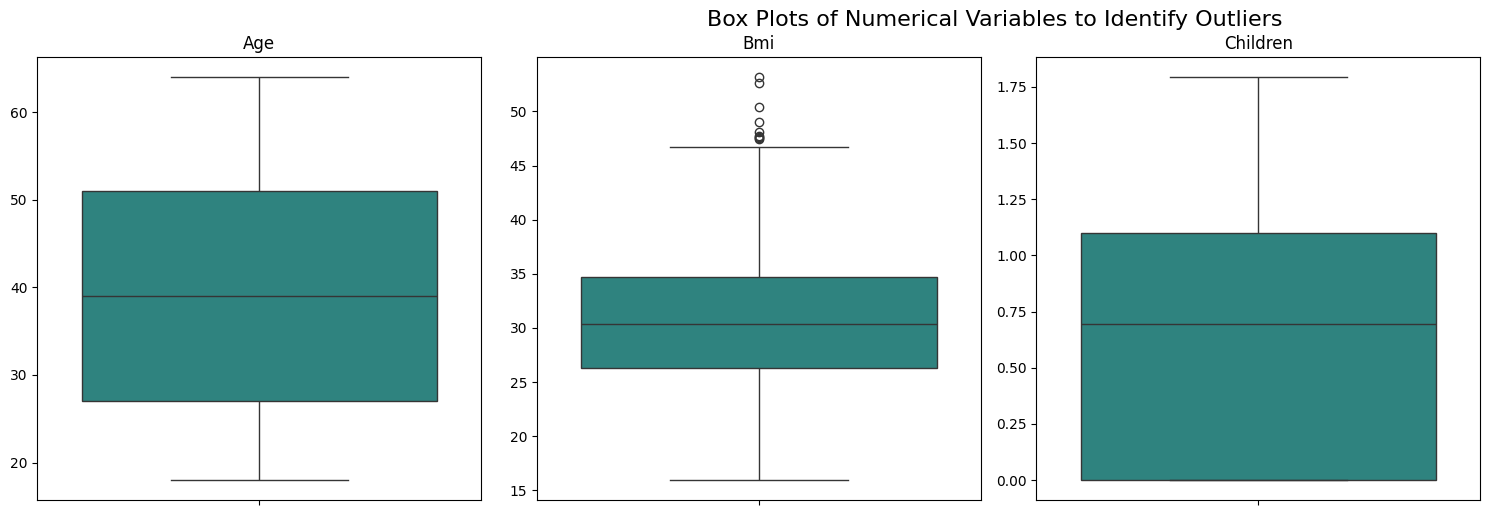

In [189]:
# outlier detection

predictors = [col for col in ['Age', 'Bmi', 'Children'] if col in df_eda.columns]
num_plots = len(predictors)
num_rows = (num_plots + 3) // 4  # Adjust for 4 plots per row
num_cols = 4

fig, axes = plt.subplots(num_rows, num_cols, figsize=(20, 5 * num_rows))
axes = axes.flatten()

for i, col in enumerate(predictors):
    sns.boxplot(y=df_eda[col], ax=axes[i], palette='viridis')
    axes[i].set_title(col, fontsize=12)
    axes[i].set_ylabel('') # Remove y-label for cleaner look
    axes[i].tick_params(axis='y', labelsize=10)

# Hide any unused subplots
for i in range(num_plots, len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.suptitle('Box Plots of Numerical Variables to Identify Outliers', y=1.02, fontsize=16)
plt.show()

In [190]:
def Get_iqr_bounds(p_df, p_column):
    Q1 = p_df[p_column].quantile(0.25)
    Q3 = p_df[p_column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - (1.5 * IQR)
    upper_bound = Q3 + (1.5 * IQR)
    return lower_bound, upper_bound
    
def handle_outliers(p_df, p_column):
    lower_bound, upper_bound = Get_iqr_bounds(p_df, p_column)
    print("handle_outliers :: " + p_column + " : lower_bound : ", lower_bound, ", upper_bound : ", upper_bound)
    #capping values outside the bounds
    p_df[p_column] = np.where((p_df[p_column] < lower_bound), lower_bound, p_df[p_column])
    p_df[p_column] = np.where((p_df[p_column] > upper_bound), upper_bound, p_df[p_column])

def Get_outliers_percentage(p_df, p_column):
    lower_bound, upper_bound = Get_iqr_bounds(p_df, p_column)
    total_count = len(p_df)
    outliers_count = p_df[(p_df[p_column] < lower_bound) | (p_df[p_column] > upper_bound)].shape[0]
    outliers_percentage = (outliers_count / total_count) * 100
    print(f"Get_outliers_percentage :: {p_column} : Outliers Percentage: {outliers_percentage:.2f}% , outliers_count : {outliers_count} , total_count : {total_count}")
    return outliers_percentage

#Handling outliers by capping them using IQR method if outliers percentage is less than or equal to 5%
for col in predictors:
    if Get_outliers_percentage(df_eda, col) <= 5:
        handle_outliers(df_eda, col)

Get_outliers_percentage :: Age : Outliers Percentage: 0.00% , outliers_count : 0 , total_count : 1338
handle_outliers :: Age : lower_bound :  -9.0 , upper_bound :  87.0
Get_outliers_percentage :: Bmi : Outliers Percentage: 0.67% , outliers_count : 9 , total_count : 1338
handle_outliers :: Bmi : lower_bound :  13.7 , upper_bound :  47.290000000000006
Get_outliers_percentage :: Children : Outliers Percentage: 0.00% , outliers_count : 0 , total_count : 1338
handle_outliers :: Children : lower_bound :  -1.6479184330021646 , upper_bound :  2.7465307216702746


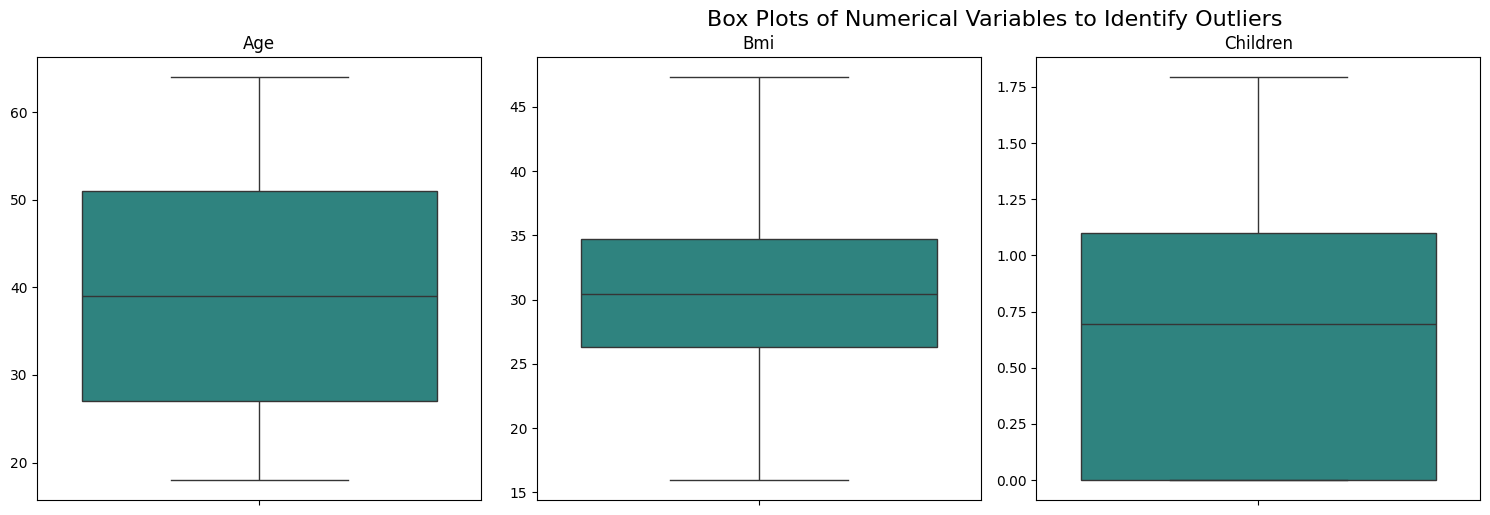

In [191]:
# distribution post outlier detection

num_plots = len(predictors)
num_rows = (num_plots + 3) // 4  # Adjust for 4 plots per row
num_cols = 4

fig, axes = plt.subplots(num_rows, num_cols, figsize=(20, 5 * num_rows))
axes = axes.flatten()

for i, col in enumerate(predictors):
    sns.boxplot(y=df_eda[col], ax=axes[i], palette='viridis')
    axes[i].set_title(col, fontsize=12)
    axes[i].set_ylabel('') # Remove y-label for cleaner look
    axes[i].tick_params(axis='y', labelsize=10)

# Hide any unused subplots
for i in range(num_plots, len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.suptitle('Box Plots of Numerical Variables to Identify Outliers', y=1.02, fontsize=16)
plt.show()

In [192]:
df_eda.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1338.0,39.207025,14.049960,18.0000,27.00000,39.000000,51.000000,64.000000
Bmi,1338.0,30.650034,6.056926,15.9600,26.29625,30.400000,34.693750,47.290000
Children,1338.0,0.581751,0.558325,0.0000,0.00000,0.693147,1.098612,1.791759
Charges,1338.0,13270.422265,12110.011237,1121.8739,4740.28715,9382.033000,16639.912515,63770.428010
Sex,1338.0,0.505232,0.500160,0.0000,0.00000,1.000000,1.000000,1.000000
Smoker,1338.0,0.204783,0.403694,0.0000,0.00000,0.000000,0.000000,1.000000
Region_NorthWest,1338.0,0.242900,0.428995,0.0000,0.00000,0.000000,0.000000,1.000000
Region_SouthEast,1338.0,0.272048,0.445181,0.0000,0.00000,0.000000,1.000000,1.000000
Region_SouthWest,1338.0,0.242900,0.428995,0.0000,0.00000,0.000000,0.000000,1.000000


In [193]:
x = df_eda.drop(columns=['Charges'])
y = df_eda['Charges']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

print("Model evaluation with EDA & without scaling :")
EndToEndEvaluation(models, x_train, y_train, x_test, y_test)

Model evaluation with EDA & without scaling :


,Model,Train R2,Test R2,Train Adjusted R2,Test Adjusted R2,Train RMSE,Test RMSE,Train MAE,Test MAE,Overfitting (Y/N)
0,GradientBoostingRegressor,0.8996,0.8792,0.8989,0.8754,3806.3766,4331.1813,2096.5810,2446.2028,N
1,RandomForestRegressor,0.9740,0.8654,0.9738,0.8613,1937.4130,4570.9436,1067.5139,2548.9190,Y
2,XGBRegressor,0.9942,0.8409,0.9942,0.8360,913.9807,4970.1153,487.5238,2788.5751,Y
3,AdaBoostRegressor,0.8146,0.8213,0.8132,0.8158,5173.0364,5267.0605,4258.3126,4421.2593,N
4,LinearRegression,0.7422,0.7829,0.7402,0.7762,6100.1660,5805.8148,4215.6009,4206.2645,N
5,Lasso,0.7422,0.7828,0.7402,0.7761,6100.1713,5806.5950,4215.9711,4207.5240,N
6,Ridge,0.7422,0.7826,0.7402,0.7758,6100.4119,5810.1531,4225.2909,4218.7591,N
7,DecisionTreeRegressor,0.9983,0.6968,0.9983,0.6874,494.2060,6861.2411,29.5725,3384.4735,Y
8,VotingRegressor,0.7232,0.6705,0.7211,0.6603,6320.7450,7152.4784,4075.2401,4791.9909,Y
9,ElasticNet,0.3831,0.4161,0.3785,0.3981,9435.9933,9520.6938,7281.9641,7441.5735,N


In [194]:
#Feature scaling

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

print("x_train :", x_train.shape)
print("x_test :", x_test.shape)
print("y_train :", y_train.shape)
print("y_test :", y_test.shape)

print("Model evaluation with EDA & scaling :")
EndToEndEvaluation(models, x_train_scaled, y_train, x_test_scaled, y_test)

x_train : (1070, 8)
x_test : (268, 8)
y_train : (1070,)
y_test : (268,)
Model evaluation with EDA & scaling :


,Model,Train R2,Test R2,Train Adjusted R2,Test Adjusted R2,Train RMSE,Test RMSE,Train MAE,Test MAE,Overfitting (Y/N)
0,GradientBoostingRegressor,0.8996,0.8792,0.8989,0.8754,3806.3766,4331.1813,2096.5810,2446.2028,N
1,RandomForestRegressor,0.9741,0.8655,0.9739,0.8613,1933.9385,4570.3635,1062.2045,2545.2188,Y
2,XGBRegressor,0.9942,0.8409,0.9942,0.8360,913.9807,4970.1153,487.5238,2788.5751,Y
3,AdaBoostRegressor,0.8146,0.8213,0.8132,0.8158,5173.0364,5267.0605,4258.3126,4421.2593,N
4,KNeighborsRegressor,0.8587,0.8032,0.8576,0.7971,4516.7515,5527.8824,2755.8388,3502.0785,Y
5,VotingRegressor,0.8168,0.7884,0.8154,0.7819,5142.7901,5731.3399,3302.4105,3809.9369,N
6,Lasso,0.7422,0.7829,0.7402,0.7761,6100.1673,5806.1697,4215.5280,4206.5762,N
7,LinearRegression,0.7422,0.7829,0.7402,0.7762,6100.1660,5805.8148,4215.6009,4206.2645,N
8,Ridge,0.7422,0.7828,0.7402,0.7761,6100.1741,5806.5218,4216.7618,4207.9105,N
9,DecisionTreeRegressor,0.9983,0.7074,0.9983,0.6984,494.2060,6739.8112,29.5725,3303.5160,Y


In [195]:
# Calculate VIF for each feature
vif1 = df_eda.copy()
vif1.drop(columns=['Charges'], inplace=True)

variable1 = vif1
vif_data1 = pd.DataFrame()
vif_data1['Variance Inflation Factor'] = [variance_inflation_factor(variable1, i) for i in range(variable1.shape[1])]
vif_data1['Features'] = vif1.columns

vif_data1.sort_values(by="Variance Inflation Factor", ascending=False)

,Variance Inflation Factor,Features
1,11.511180,Bmi
0,7.737628,Age
6,2.264745,Region_SouthEast
2,2.062553,Children
3,2.002722,Sex
7,1.961968,Region_SouthWest
5,1.893659,Region_NorthWest
4,1.261685,Smoker


In [196]:
vif2 = vif1.copy()
vif2.drop(columns=['Bmi'], inplace=True)

variable2 = vif2
vif_data2 = pd.DataFrame()
vif_data2['Variance Inflation Factor'] = [variance_inflation_factor(variable2, i) for i in range(variable2.shape[1])]
vif_data2['Features'] = vif2.columns

vif_data2.sort_values(by="Variance Inflation Factor", ascending=False)

,Variance Inflation Factor,Features
0,3.950897,Age
1,1.991489,Children
2,1.886742,Sex
5,1.801785,Region_SouthEast
6,1.718803,Region_SouthWest
4,1.714657,Region_NorthWest
3,1.250759,Smoker


In [197]:
df_vif = df_eda.copy()
x = df_vif.drop(columns=['Bmi', 'Charges'])
y = df_vif['Charges']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

print("Model evaluation with EDA & VIF (without scaling) :")
EndToEndEvaluation(models, x_train, y_train, x_test, y_test)

Model evaluation with EDA & VIF (without scaling) :


,Model,Train R2,Test R2,Train Adjusted R2,Test Adjusted R2,Train RMSE,Test RMSE,Train MAE,Test MAE,Overfitting (Y/N)
0,LinearRegression,0.7156,0.7574,0.7137,0.7509,6407.1685,6137.1434,4146.9300,3931.4201,N
1,Lasso,0.7156,0.7574,0.7137,0.7508,6407.1707,6137.3815,4147.8422,3932.6354,N
2,GradientBoostingRegressor,0.7740,0.7574,0.7725,0.7508,5711.3375,6137.4368,3614.3413,3893.0332,N
3,Ridge,0.7156,0.7571,0.7137,0.7506,6407.4002,6140.3152,4164.3084,3951.4330,N
4,RandomForestRegressor,0.9186,0.7328,0.9180,0.7256,3428.5281,6441.2802,1988.1101,3834.5120,Y
5,AdaBoostRegressor,0.6657,0.6901,0.6635,0.6817,6946.4008,6936.5627,6006.7429,5977.8564,N
6,VotingRegressor,0.7110,0.6515,0.7091,0.6421,6458.4056,7355.5119,3984.9840,4593.3840,Y
7,XGBRegressor,0.9476,0.6311,0.9472,0.6212,2750.6717,7567.5885,1431.5487,4421.6977,Y
8,DecisionTreeRegressor,0.9588,0.5400,0.9585,0.5277,2438.3832,8450.2932,737.6792,4247.5154,Y
9,KNeighborsRegressor,0.6154,0.5357,0.6128,0.5232,7450.7781,8489.7865,4464.6596,5107.6423,Y


In [198]:
scaler1 = StandardScaler()

x_train_scaled = scaler1.fit_transform(x_train)
x_test_scaled = scaler1.transform(x_test)

print("Model evaluation with EDA & VIF (with scaling) :")
EndToEndEvaluation(models, x_train_scaled, y_train, x_test_scaled, y_test)

Model evaluation with EDA & VIF (with scaling) :


,Model,Train R2,Test R2,Train Adjusted R2,Test Adjusted R2,Train RMSE,Test RMSE,Train MAE,Test MAE,Overfitting (Y/N)
0,LinearRegression,0.7156,0.7574,0.7137,0.7509,6407.1685,6137.1434,4146.9300,3931.4201,N
1,Ridge,0.7156,0.7574,0.7137,0.7508,6407.1760,6137.6136,4149.7518,3934.7335,N
2,Lasso,0.7156,0.7574,0.7137,0.7509,6407.1690,6137.2480,4147.2899,3931.9462,N
3,GradientBoostingRegressor,0.7740,0.7574,0.7725,0.7508,5711.3375,6137.4368,3614.3413,3893.0332,N
4,RandomForestRegressor,0.9190,0.7331,0.9185,0.7260,3419.4531,6436.5135,1982.1796,3832.2050,Y
5,VotingRegressor,0.7578,0.6948,0.7562,0.6866,5912.7446,6883.5826,3761.8274,4448.4124,Y
6,KNeighborsRegressor,0.7749,0.6935,0.7734,0.6852,5699.6971,6898.2289,3371.1775,4241.4721,Y
7,AdaBoostRegressor,0.6657,0.6901,0.6635,0.6817,6946.4008,6936.5627,6006.7429,5977.8564,N
8,ElasticNet,0.6331,0.6612,0.6307,0.6521,7277.3304,7252.7144,5318.0191,5314.6030,N
9,XGBRegressor,0.9476,0.6311,0.9472,0.6212,2750.6717,7567.5885,1431.5487,4421.6977,Y


#### Observation : GradientBoostingRegressor is best performing model with or without EDA & scaling : Train R2 : 0.8996 , Test_R2 : 0.8792 , Train_RMSE : 3806.3766 , Test_RMSE : 4331.1813

In [199]:
best_performing_model = models[8]

l_param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [2, 3, 4],
    'min_samples_split': [2, 5, 10],
    'learning_rate': [0.01, 0.1, 0.2]
}

x = df_eda.drop(columns=['Charges'])
y = df_eda['Charges']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
x_train_scaled = scaler.transform(x_train)
x_test_scaled = scaler.transform(x_test)
grid_search = GridSearchCV(estimator=best_performing_model, param_grid=l_param_grid, cv=5, n_jobs=-1, verbose=2)
grid_search.fit(x_train_scaled, y_train)

best_model_GSCV = grid_search.best_estimator_
print("Best Hyperparameters for GradientBoostingRegressor model:", grid_search.best_params_)

Fitting 5 folds for each of 81 candidates, totalling 405 fits
Best Hyperparameters for GradientBoostingRegressor model: {'learning_rate': 0.1, 'max_depth': 2, 'min_samples_split': 10, 'n_estimators': 100}


In [200]:
l_models = [best_model_GSCV]
print("Best Model evaluation with EDA & scaling (GridSearchCV) :")
EndToEndEvaluation(l_models, x_train_scaled, y_train, x_test_scaled, y_test)

Best Model evaluation with EDA & scaling (GridSearchCV) :


,Model,Train R2,Test R2,Train Adjusted R2,Test Adjusted R2,Train RMSE,Test RMSE,Train MAE,Test MAE,Overfitting (Y/N)
0,GradientBoostingRegressor,0.8762,0.8784,0.8752,0.8747,4227.9252,4344.3966,2375.6924,2474.6304,N


#### Best Hyperparameters for GradientBoostingRegressor model: {'learning_rate': 0.1, 'max_depth': 2, 'min_samples_split': 10, 'n_estimators': 100}

#### Pre hyperparameter tuning :	Train R2 : 0.8996 , Test_R2 : 0.8792 , Train_RMSE : 3806.3766 , Test_RMSE : 4331.1813
#### Post hyperparameter tuning :	Train R2 : 0.8762 ,	Test R2 : 0.8784 , Train RMSE : 4227.9252 , Test RMSE : 4344.3966

#### Conclusion : Selecting GradientBoostingRegressor model with eda & scaling

In [201]:
x = df_eda.drop(columns=['Charges'])
y = df_eda['Charges']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
x_train_scaled = scaler.transform(x_train)
x_test_scaled = scaler.transform(x_test)
print("Best Model evaluation with EDA & scaling :")
EndToEndEvaluation(models, x_train_scaled, y_train, x_test_scaled, y_test)

Best Model evaluation with EDA & scaling :


,Model,Train R2,Test R2,Train Adjusted R2,Test Adjusted R2,Train RMSE,Test RMSE,Train MAE,Test MAE,Overfitting (Y/N)
0,GradientBoostingRegressor,0.8996,0.8792,0.8989,0.8754,3806.3766,4331.1813,2096.5810,2446.2028,N
1,RandomForestRegressor,0.9741,0.8655,0.9739,0.8613,1933.9385,4570.3635,1062.2045,2545.2188,Y
2,XGBRegressor,0.9942,0.8409,0.9942,0.8360,913.9807,4970.1153,487.5238,2788.5751,Y
3,AdaBoostRegressor,0.8146,0.8213,0.8132,0.8158,5173.0364,5267.0605,4258.3126,4421.2593,N
4,KNeighborsRegressor,0.8587,0.8032,0.8576,0.7971,4516.7515,5527.8824,2755.8388,3502.0785,Y
5,VotingRegressor,0.8168,0.7884,0.8154,0.7819,5142.7901,5731.3399,3302.4105,3809.9369,N
6,Lasso,0.7422,0.7829,0.7402,0.7761,6100.1673,5806.1697,4215.5280,4206.5762,N
7,LinearRegression,0.7422,0.7829,0.7402,0.7762,6100.1660,5805.8148,4215.6009,4206.2645,N
8,Ridge,0.7422,0.7828,0.7402,0.7761,6100.1741,5806.5218,4216.7618,4207.9105,N
9,DecisionTreeRegressor,0.9983,0.7074,0.9983,0.6984,494.2060,6739.8112,29.5725,3303.5160,Y


In [203]:
best_performing_model = models[8]

#dump the best performing model which is GradientBoostingRegressor model before hyperparameter tuning using GridSearchCV and the scaler object for future use in inference
joblib.dump(best_performing_model, 'GradientBoostingRegressor_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

In [204]:
df_eda.head()

,Age,Bmi,Children,Charges,Sex,Smoker,Region_NorthWest,Region_SouthEast,Region_SouthWest
0,19.0,27.900,0.000000,16884.92400,0,1,0,0,1
1,18.0,33.770,0.693147,1725.55230,1,0,0,1,0
2,28.0,33.000,1.386294,4449.46200,1,0,0,1,0
3,33.0,22.705,0.000000,21984.47061,1,0,1,0,0
4,32.0,28.880,0.000000,3866.85520,1,0,1,0,0


In [205]:
df_eda.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Age               1338 non-null   float64
 1   Bmi               1338 non-null   float64
 2   Children          1338 non-null   float64
 3   Charges           1338 non-null   float64
 4   Sex               1338 non-null   int64  
 5   Smoker            1338 non-null   int64  
 6   Region_NorthWest  1338 non-null   int64  
 7   Region_SouthEast  1338 non-null   int64  
 8   Region_SouthWest  1338 non-null   int64  
dtypes: float64(4), int64(5)
memory usage: 94.2 KB


In [206]:
df_eda.columns

Index(['Age', 'Bmi', 'Children', 'Charges', 'Sex', 'Smoker',
       'Region_NorthWest', 'Region_SouthEast', 'Region_SouthWest'],
      dtype='str')